In [38]:
import pandas as pd

In [39]:
df = pd.read_csv(r"C:\Users\ujjai\Downloads\Google Playstore Apps.csv")

In [40]:
df.head()

,Unnamed: 0,App,Category,Rating,Reviews,Installs,Type,Price,Genres,Last Updated
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,10000,Free,0.0,Art & Design,2018-01-07
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,500000,Free,0.0,Art & Design;Pretend Play,2018-01-15
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,5000000,Free,0.0,Art & Design,2018-08-01
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,50000000,Free,0.0,Art & Design,2018-06-08
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,100000,Free,0.0,Art & Design;Creativity,2018-06-20


In [10]:
df.shape

(9745, 10)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9745 entries, 0 to 9744
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    9745 non-null   int64  
 1   App           9745 non-null   str    
 2   Category      9745 non-null   str    
 3   Rating        8281 non-null   float64
 4   Reviews       9745 non-null   int64  
 5   Installs      9745 non-null   int64  
 6   Type          9744 non-null   str    
 7   Price         9745 non-null   float64
 8   Genres        9745 non-null   str    
 9   Last Updated  9745 non-null   str    
dtypes: float64(2), int64(3), str(5)
memory usage: 761.5 KB


In [12]:
df.describe()

,Unnamed: 0,Rating,Reviews,Installs,Price
count,9745.000000,8281.000000,9.745000e+03,9.745000e+03,9745.000000
mean,5660.108979,4.175088,2.380746e+05,8.203052e+06,1.090622
std,3099.061767,0.534714,1.934311e+06,5.527622e+07,16.778026
min,0.000000,1.000000,0.000000e+00,0.000000e+00,0.000000
25%,3110.000000,4.000000,2.600000e+01,1.000000e+03,0.000000
50%,5798.000000,4.300000,1.016000e+03,1.000000e+05,0.000000
75%,8318.000000,4.500000,3.069300e+04,1.000000e+06,0.000000
max,10840.000000,5.000000,7.815831e+07,1.000000e+09,400.000000


In [13]:
df.isnull().sum()

Unnamed: 0         0
App                0
Category           0
Rating          1464
Reviews            0
Installs           0
Type               1
Price              0
Genres             0
Last Updated       0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [16]:
df.shape

(9745, 9)

In [17]:
df[df['Rating'].isnull()].head(10)

,App,Category,Rating,Reviews,Installs,Type,Price,Genres,Last Updated
23,Mcqueen Coloring pages,ART_AND_DESIGN,NaN,61,100000,Free,0.0,Art & Design;Action & Adventure,2018-03-07
113,Wrinkles and rejuvenation,BEAUTY,NaN,182,100000,Free,0.0,Beauty,2017-09-20
123,Manicure - nail design,BEAUTY,NaN,119,50000,Free,0.0,Beauty,2018-07-23
126,Skin Care and Natural Beauty,BEAUTY,NaN,654,100000,Free,0.0,Beauty,2018-07-17
129,"Secrets of beauty, youth and health",BEAUTY,NaN,77,10000,Free,0.0,Beauty,2017-08-08
130,Recipes and tips for losing weight,BEAUTY,NaN,35,10000,Free,0.0,Beauty,2017-12-11
134,"Lady adviser (beauty, health)",BEAUTY,NaN,30,10000,Free,0.0,Beauty,2018-01-24
163,Anonymous caller detection,BOOKS_AND_REFERENCE,NaN,161,10000,Free,0.0,Books & Reference,2018-07-13
180,SH-02J Owner's Manual (Android 8.0),BOOKS_AND_REFERENCE,NaN,2,50000,Free,0.0,Books & Reference,2018-06-15
185,URBANO V 02 instruction manual,BOOKS_AND_REFERENCE,NaN,114,100000,Free,0.0,Books & Reference,2015-08-07


In [18]:
df[df['Rating'].isnull()].shape

(1464, 9)

In [19]:
df.groupby('Category')['Rating'].mean().sort_values(ascending=False)

Category
EVENTS                 4.435556
EDUCATION              4.364407
ART_AND_DESIGN         4.357377
BOOKS_AND_REFERENCE    4.344970
PERSONALIZATION        4.332215
PARENTING              4.300000
BEAUTY                 4.278571
GAME                   4.247645
SOCIAL                 4.247291
WEATHER                4.243056
HEALTH_AND_FITNESS     4.243033
SHOPPING               4.230000
SPORTS                 4.218702
AUTO_AND_VEHICLES      4.190411
FAMILY                 4.187173
PRODUCTIVITY           4.183389
COMICS                 4.181481
LIBRARIES_AND_DEMO     4.178125
FOOD_AND_DRINK         4.172340
MEDICAL                4.169178
PHOTOGRAPHY            4.157414
HOUSE_AND_HOME         4.150000
ENTERTAINMENT          4.135294
NEWS_AND_MAGAZINES     4.121569
COMMUNICATION          4.121401
FINANCE                4.115563
BUSINESS               4.098479
LIFESTYLE              4.093355
TRAVEL_AND_LOCAL       4.069519
VIDEO_PLAYERS          4.044966
TOOLS                  4.040556

In [20]:
df['Rating'].isnull().sum()

np.int64(1464)

In [21]:
df['Rating'] = df.groupby('Category')['Rating'].transform(
    lambda x: x.fillna(x.mean())
)

In [22]:
df['Rating'].isnull().sum()

np.int64(0)

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
category_reviews = df.groupby('Category')['Reviews'].mean().sort_values(ascending=False)
category_reviews

Category
SOCIAL                 953672.807531
COMMUNICATION          904521.825949
GAME                   649661.142708
VIDEO_PLAYERS          412464.573171
PHOTOGRAPHY            374915.551601
ENTERTAINMENT          340810.294118
TOOLS                  276748.525935
SHOPPING               220553.118812
SPORTS                 181673.373089
FAMILY                 181252.127292
WEATHER                155634.987342
PRODUCTIVITY           148638.098930
PERSONALIZATION        142401.808511
MAPS_AND_NAVIGATION    135337.007634
TRAVEL_AND_LOCAL       122464.570776
EDUCATION              112303.764706
NEWS_AND_MAGAZINES      91063.889764
BOOKS_AND_REFERENCE     75321.234234
HEALTH_AND_FITNESS      74171.371528
FOOD_AND_DRINK          56473.464286
COMICS                  41822.696429
FINANCE                 36701.756522
LIFESTYLE               32066.859079
HOUSE_AND_HOME          26079.013514
BUSINESS                23548.202381
ART_AND_DESIGN          22175.046875
DATING                  21190

In [26]:
df[['Installs', 'Reviews']].corr()

,Installs,Reviews
Installs,1.000000,0.612695
Reviews,0.612695,1.000000


In [30]:
df['Type'].value_counts()

Type
Free    8986
Paid     758
Name: count, dtype: int64

In [31]:
df.groupby('Type')['Rating'].mean()

Type
Free    4.16776
Paid    4.24845
Name: Rating, dtype: float64

In [32]:
df[df['Type'] == 'Paid']['Price'].describe()

count    758.000000
mean      14.021253
std       58.667827
min        0.990000
25%        1.490000
50%        2.990000
75%        4.990000
max      400.000000
Name: Price, dtype: float64

In [33]:
df[df['Type'] == 'Paid'].sort_values('Price', ascending=False)[
    ['App', 'Category', 'Price', 'Rating', 'Reviews']
].head(10)

,App,Category,Price,Rating,Reviews
3517,I'm Rich - Trump Edition,LIFESTYLE,400.00,3.600000,275
4468,I am Rich,FINANCE,399.99,4.300000,180
8863,I'm Rich/Eu sou Rico/أنا غني/我很有錢,LIFESTYLE,399.99,4.093355,0
4457,I am Rich!,FINANCE,399.99,3.800000,93
4458,I am rich(premium),FINANCE,399.99,3.500000,472
3370,most expensive app (H),FAMILY,399.99,4.300000,6
4453,I am Rich Plus,FAMILY,399.99,4.000000,856
4451,I am rich,LIFESTYLE,399.99,3.800000,3547
4455,I Am Rich Premium,FINANCE,399.99,4.100000,1867
4463,I am rich (Most expensive app),FINANCE,399.99,4.100000,129


In [34]:
df[df['Type'] == 'Paid'][['Price', 'Rating']].corr()

,Price,Rating
Price,1.000000,-0.107002
Rating,-0.107002,1.000000


In [35]:
pd.crosstab(df['Category'], df['Type'])

Type,Free,Paid
Category,,
ART_AND_DESIGN,61,3
AUTO_AND_VEHICLES,82,3
BEAUTY,53,0
BOOKS_AND_REFERENCE,194,28
BUSINESS,408,12
COMICS,56,0
COMMUNICATION,289,27
DATING,165,6
EDUCATION,115,4


In [37]:
df['Rating'].value_counts()

Rating
4.300000    922
4.400000    909
4.500000    862
4.200000    817
4.600000    694
           ... 
1.400000      3
1.500000      3
4.181481      2
4.364407      1
1.200000      1
Name: count, Length: 70, dtype: int64

In [38]:
df.columns.tolist()

['App',
 'Category',
 'Rating',
 'Reviews',
 'Installs',
 'Type',
 'Price',
 'Genres',
 'Last Updated']

In [39]:
df['Genres'].value_counts()

Genres
Tools                       828
Entertainment               579
Education                   519
Business                    420
Medical                     397
                           ... 
Role Playing;Brain Games      1
Strategy;Education            1
Racing;Pretend Play           1
Communication;Creativity      1
Strategy;Creativity           1
Name: count, Length: 119, dtype: int64

In [40]:
genre_rating = df.groupby('Genres')['Rating'].mean().sort_values(ascending=False)

genre_rating.head(10)

Genres
Board;Pretend Play             4.800000
Comics;Creativity              4.800000
Health & Fitness;Education     4.700000
Puzzle;Education               4.600000
Strategy;Action & Adventure    4.600000
Adventure;Brain Games          4.600000
Entertainment;Creativity       4.533333
Music;Music & Video            4.533333
Tools;Education                4.500000
Strategy;Education             4.500000
Name: Rating, dtype: float64

In [41]:
df['Last Updated'].head()

0    2018-01-07
1    2018-01-15
2    2018-08-01
3    2018-06-08
4    2018-06-20
Name: Last Updated, dtype: str

In [42]:
df['Last Updated'] = pd.to_datetime(df['Last Updated'])

In [43]:
df['Last Updated'].dtype

dtype('<M8[us]')

In [44]:
df['Last Updated'].dt.year.value_counts().sort_index()

Last Updated
2010       1
2011      15
2012      26
2013     108
2014     203
2015     450
2016     780
2017    1800
2018    6362
Name: count, dtype: int64

In [45]:
df['Last Updated'].dt.month.value_counts().sort_index()

Last Updated
1      474
2      518
3      642
4      577
5      930
6     1179
7     2659
8     1298
9      306
10     382
11     363
12     417
Name: count, dtype: int64

In [46]:
df['Installs'].describe()

count    9.745000e+03
mean     8.203052e+06
std      5.527622e+07
min      0.000000e+00
25%      1.000000e+03
50%      1.000000e+05
75%      1.000000e+06
max      1.000000e+09
Name: Installs, dtype: float64

In [47]:
bins = [0, 1000, 10000, 100000, 1000000, 10000000, 100000000, 1000000000]

labels = [
    '0-1K',
    '1K-10K',
    '10K-100K',
    '100K-1M',
    '1M-10M',
    '10M-100M',
    '100M-1B'
]

df['Install Range'] = pd.cut(
    df['Installs'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df['Install Range'].value_counts().sort_index()

Install Range
0-1K        2680
1K-10K      1499
10K-100K    1584
100K-1M     1940
1M-10M      1580
10M-100M     414
100M-1B       48
Name: count, dtype: int64

In [53]:
df.columns.tolist()

['App',
 'Category',
 'Rating',
 'Reviews',
 'Installs',
 'Type',
 'Price',
 'Genres',
 'Last Updated']

In [5]:
len(df)

9745

In [6]:
#Category Analysis
#1.Which app categories have the highest number of apps?
category_counts = df['Category'].value_counts()

print(category_counts)

Category
FAMILY                 1909
GAME                    960
TOOLS                   829
BUSINESS                420
MEDICAL                 397
PERSONALIZATION         376
PRODUCTIVITY            374
LIFESTYLE               369
FINANCE                 345
SPORTS                  327
COMMUNICATION           316
HEALTH_AND_FITNESS      288
PHOTOGRAPHY             281
NEWS_AND_MAGAZINES      254
SOCIAL                  239
BOOKS_AND_REFERENCE     222
TRAVEL_AND_LOCAL        219
SHOPPING                202
DATING                  171
VIDEO_PLAYERS           164
MAPS_AND_NAVIGATION     131
EDUCATION               119
FOOD_AND_DRINK          112
ENTERTAINMENT           102
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       84
WEATHER                  79
HOUSE_AND_HOME           74
ART_AND_DESIGN           64
EVENTS                   64
PARENTING                60
COMICS                   56
BEAUTY                   53
Name: count, dtype: int64


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

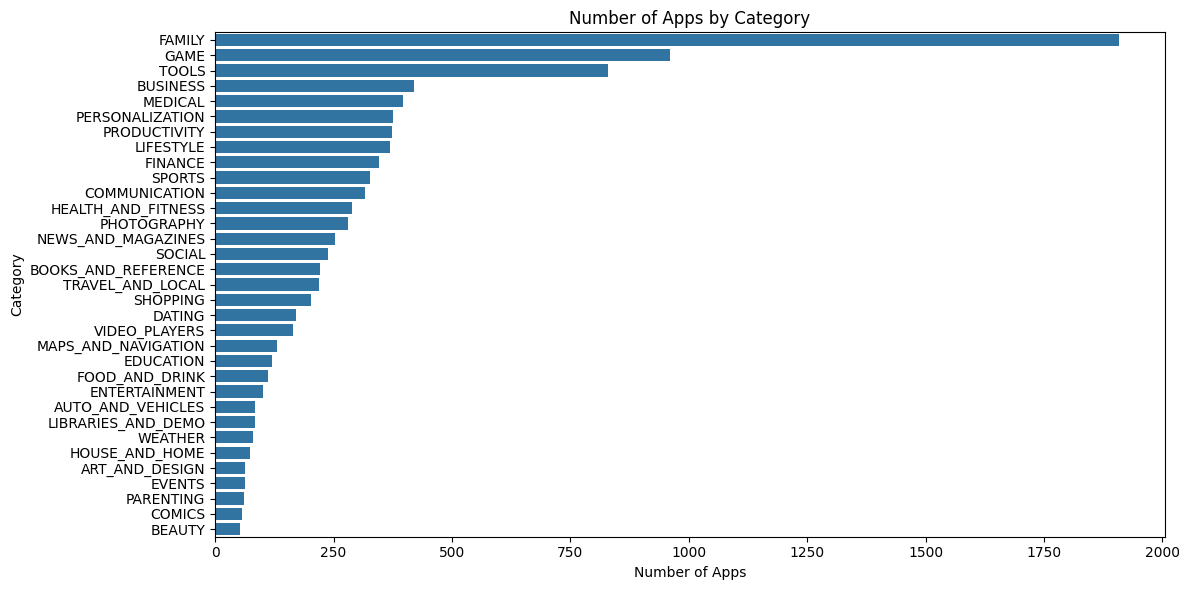

In [9]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.title('Number of Apps by Category')
plt.xlabel('Number of Apps')
plt.ylabel('Category')

plt.tight_layout()
plt.show()

In [ ]:
#Insights
#The FAMILY category dominates the dataset with 1,909 apps, followed by GAME and TOOLS. This indicates strong developer activity and competition in these segments, while categories with fewer apps may offer opportunities for niche market expansion.

In [10]:
#Category Rating Analysis
#2.Which app categories have the highest average user ratings?
category_rating = (
    df.groupby('Category')['Rating']
      .mean()
      .sort_values(ascending=False)
)

print(category_rating)

Category
EVENTS                 4.435556
EDUCATION              4.364407
ART_AND_DESIGN         4.357377
BOOKS_AND_REFERENCE    4.344970
PERSONALIZATION        4.332215
PARENTING              4.300000
BEAUTY                 4.278571
GAME                   4.247645
SOCIAL                 4.247291
WEATHER                4.243056
HEALTH_AND_FITNESS     4.243033
SHOPPING               4.230000
SPORTS                 4.218702
AUTO_AND_VEHICLES      4.190411
FAMILY                 4.187173
PRODUCTIVITY           4.183389
COMICS                 4.181481
LIBRARIES_AND_DEMO     4.178125
FOOD_AND_DRINK         4.172340
MEDICAL                4.169178
PHOTOGRAPHY            4.157414
HOUSE_AND_HOME         4.150000
ENTERTAINMENT          4.135294
NEWS_AND_MAGAZINES     4.121569
COMMUNICATION          4.121401
FINANCE                4.115563
BUSINESS               4.098479
LIFESTYLE              4.093355
TRAVEL_AND_LOCAL       4.069519
VIDEO_PLAYERS          4.044966
TOOLS                  4.040556

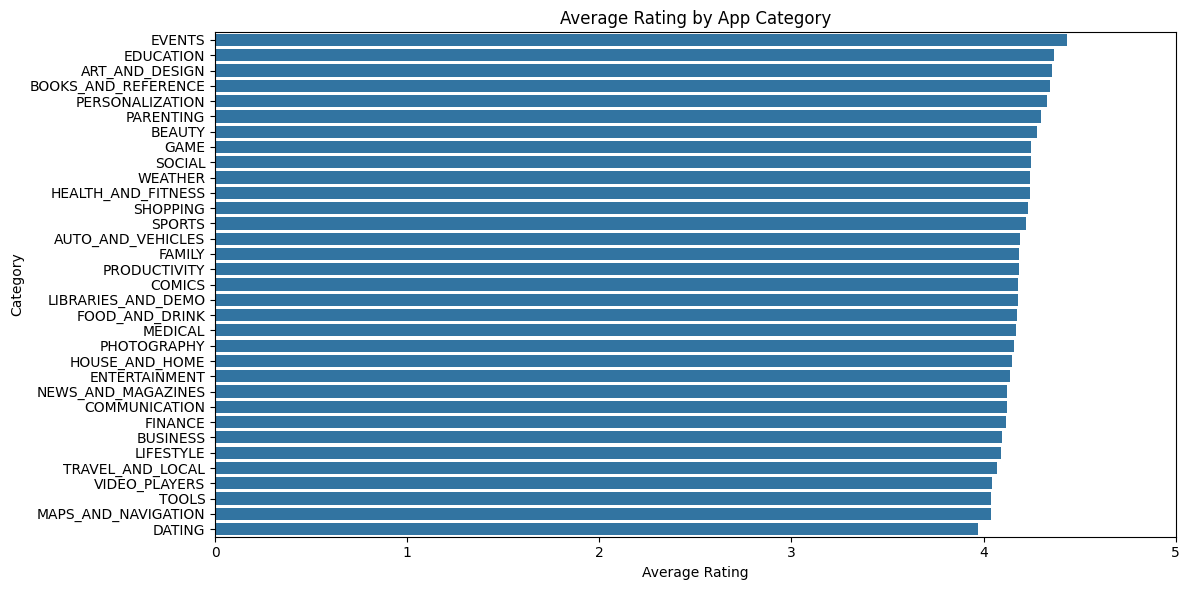

In [11]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=category_rating.values,
    y=category_rating.index
)

plt.title('Average Rating by App Category')
plt.xlabel('Average Rating')
plt.ylabel('Category')

plt.xlim(0, 5)
plt.tight_layout()
plt.show()

In [ ]:
#Insights
#EVENTS has the highest average user rating (4.44), indicating strong user satisfaction, while DATING has the lowest (3.97). Categories with lower ratings may have greater opportunities to improve user experience and app quality.

In [12]:
#App Popularity Analysis
#3.Which apps have the highest number of installs?
top_installed = df.sort_values(
    by='Installs',
    ascending=False
).head(10)

top_installed[['App', 'Installs']]

,App,Installs
2214,Google Photos,1000000000
2035,Google+,1000000000
1357,Subway Surfers,1000000000
4930,Google Play Games,1000000000
702,Google Play Games,1000000000
2954,Google Play Movies & TV,1000000000
3002,Google News,1000000000
152,Google Play Books,1000000000
2443,Maps - Navigate & Explore,1000000000
2025,Facebook,1000000000


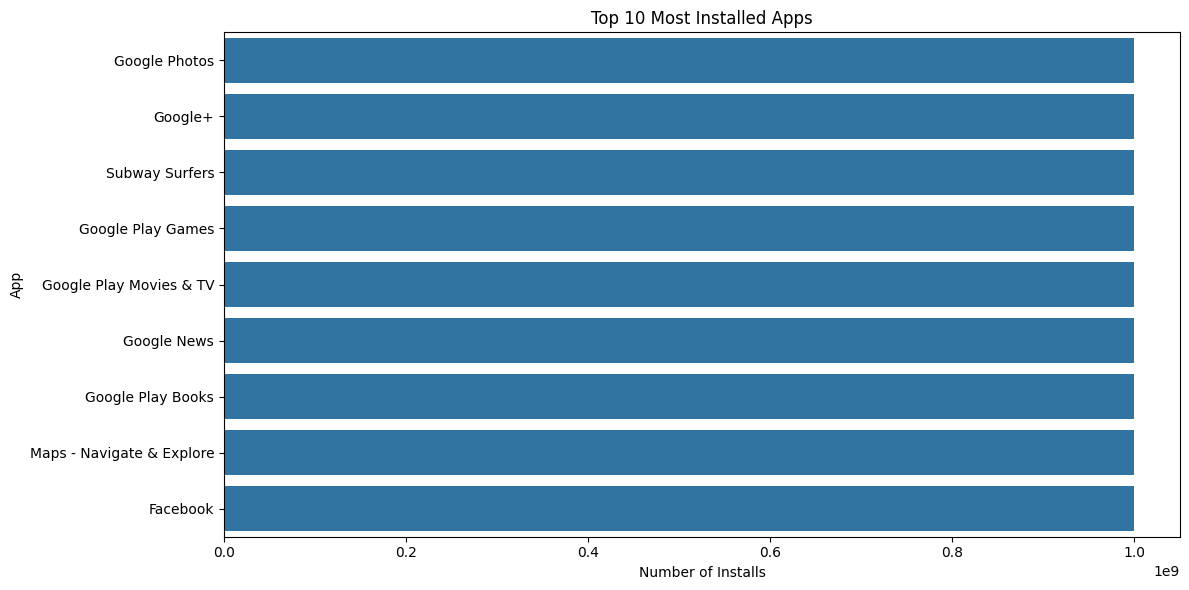

In [13]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_installed,
    x='Installs',
    y='App'
)

plt.title('Top 10 Most Installed Apps')
plt.xlabel('Number of Installs')
plt.ylabel('App')

plt.tight_layout()
plt.show()

In [ ]:
#Insights
#Several apps, including Google Photos, Google+, Subway Surfers, Google Play Games, and Facebook, have reached 1 billion installs, highlighting extremely high user adoption. The dominance of Google apps also indicates the strong impact of an established ecosystem and brand reach on app popularity.

In [14]:
#User Engagement Analysis
#4.Which apps have the highest number of user reviews?
top_reviewed = df.sort_values(
    by='Reviews',
    ascending=False
).head(10)

top_reviewed[['App', 'Reviews']]

,App,Reviews
2025,Facebook,78158306
300,WhatsApp Messenger,69119316
2026,Instagram,66577313
299,Messenger – Text and Video Chat for Free,56642847
1373,Clash of Clans,44891723
3202,Clash of Clans,44881447
3220,Clean Master- Space Cleaner & Antivirus,42916526
1357,Subway Surfers,27722264
2932,YouTube,25655305
6551,"Security Master - Antivirus, VPN, AppLock, Boo...",24900999


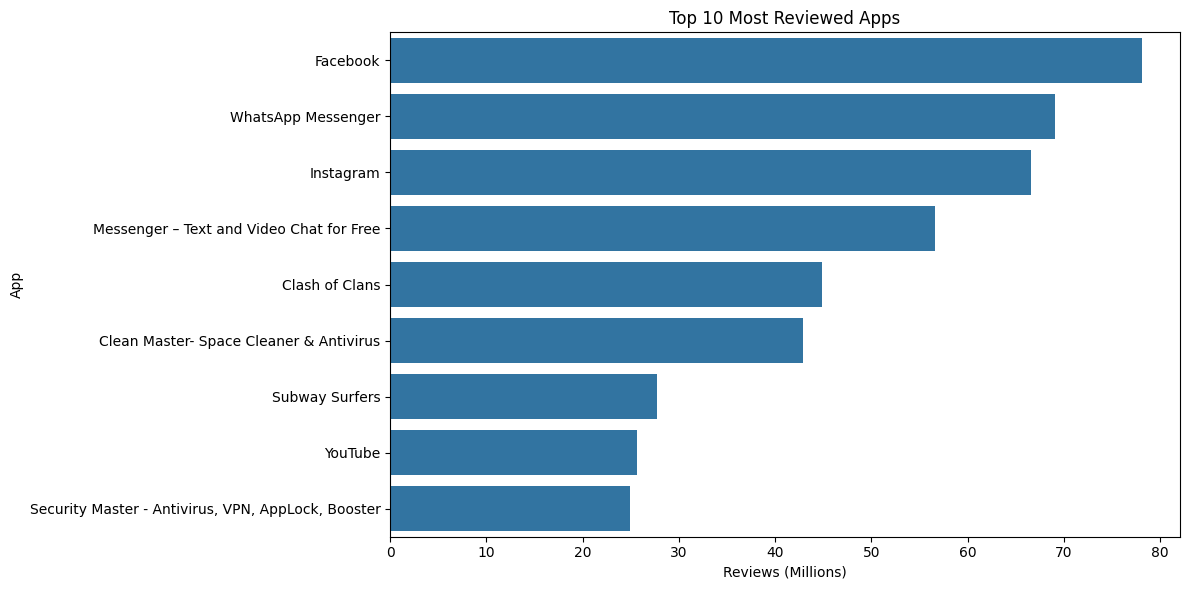

In [15]:
top_reviewed = df.sort_values(
    by='Reviews',
    ascending=False
).head(10).copy()

top_reviewed['Reviews_Millions'] = top_reviewed['Reviews'] / 1_000_000

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_reviewed,
    x='Reviews_Millions',
    y='App'
)

plt.title('Top 10 Most Reviewed Apps')
plt.xlabel('Reviews (Millions)')
plt.ylabel('App')

plt.tight_layout()
plt.show()

In [ ]:
#Insights
#Facebook, WhatsApp Messenger, and Instagram record the highest user review volumes, indicating exceptionally strong user engagement. The presence of both social-media and gaming apps among the most-reviewed applications highlights the importance of large user bases and frequent usage in driving engagement.

In [16]:
#Reviews vs Rating Analysis
#5.Does a higher number of user reviews lead to a higher app rating?
df[['Reviews', 'Rating']].describe()
correlation = df['Reviews'].corr(df['Rating'])

print("Correlation between Reviews and Rating:", round(correlation, 2))

Correlation between Reviews and Rating: 0.06


In [ ]:
#Insights
#The correlation between reviews and ratings is only 0.06, indicating a very weak positive relationship. This suggests that a higher number of user reviews does not necessarily lead to better app ratings, as popularity and user satisfaction are different aspects of app performance.

In [19]:
#Free vs Paid App Analysis
#6.Are free apps more popular than paid apps?
type_analysis = df.groupby('Type').agg(
    Total_Apps=('App', 'count'),
    Average_Rating=('Rating', 'mean'),
    Average_Reviews=('Reviews', 'mean'),
    Average_Installs=('Installs', 'mean')
).round(2)

type_analysis

,Total_Apps,Average_Rating,Average_Reviews,Average_Installs
Type,,,,
Free,8986,4.17,257445.96,8889480.60
Paid,758,4.26,8742.92,76340.21


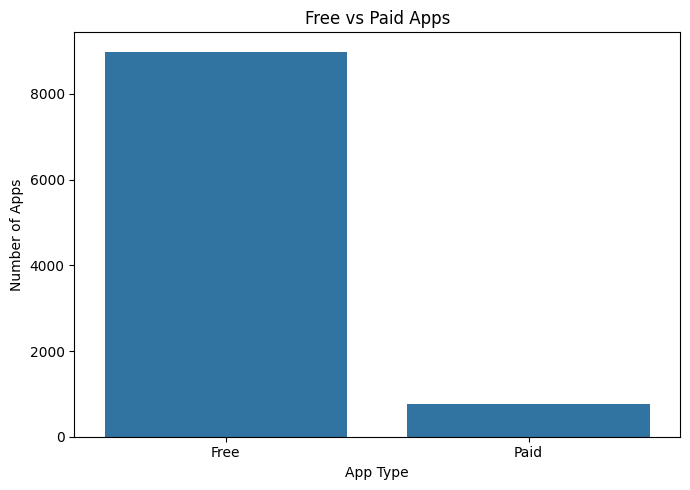

In [20]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='Type'
)

plt.title('Free vs Paid Apps')
plt.xlabel('App Type')
plt.ylabel('Number of Apps')

plt.tight_layout()
plt.show()

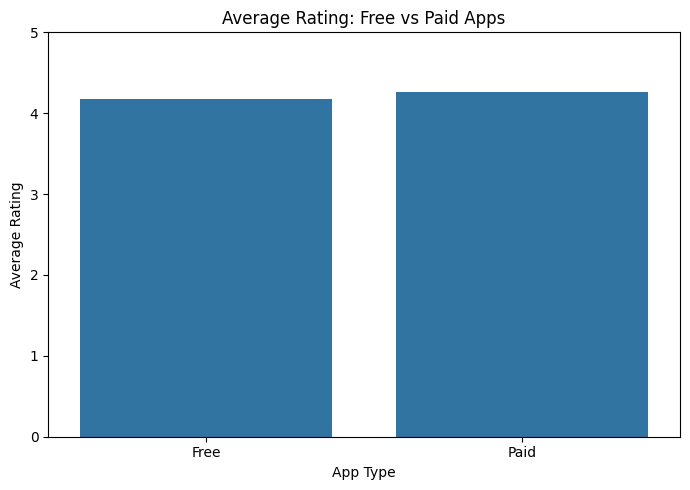

In [21]:
#Average Rating Comparison
plt.figure(figsize=(7, 5))

sns.barplot(
    data=type_analysis.reset_index(),
    x='Type',
    y='Average_Rating'
)

plt.title('Average Rating: Free vs Paid Apps')
plt.xlabel('App Type')
plt.ylabel('Average Rating')

plt.ylim(0, 5)
plt.tight_layout()
plt.show()

In [ ]:
#Insights
#Free apps demonstrate significantly higher popularity and user engagement than paid apps, with much higher average installs and reviews. However, paid apps achieve a slightly higher average rating (4.26 vs 4.17), suggesting that popularity and user satisfaction are not necessarily directly related.

In [22]:
#Price vs Rating Analysis
#7.Does the price of a paid app affect its user rating?
paid_apps = df[df['Type'] == 'Paid'].copy()

paid_apps[['App', 'Price', 'Rating']].head()

,App,Price,Rating
233,TurboScan: scan documents and receipts in PDF,4.99,4.7
234,Tiny Scanner Pro: PDF Doc Scan,4.99,4.8
372,Puffin Browser Pro,3.99,4.0
407,"Moco+ - Chat, Meet People",3.99,4.2
408,Calculator,6.99,2.6


In [23]:
price_rating_corr = paid_apps['Price'].corr(paid_apps['Rating'])

print("Correlation between Price and Rating:", round(price_rating_corr, 2))

Correlation between Price and Rating: -0.11


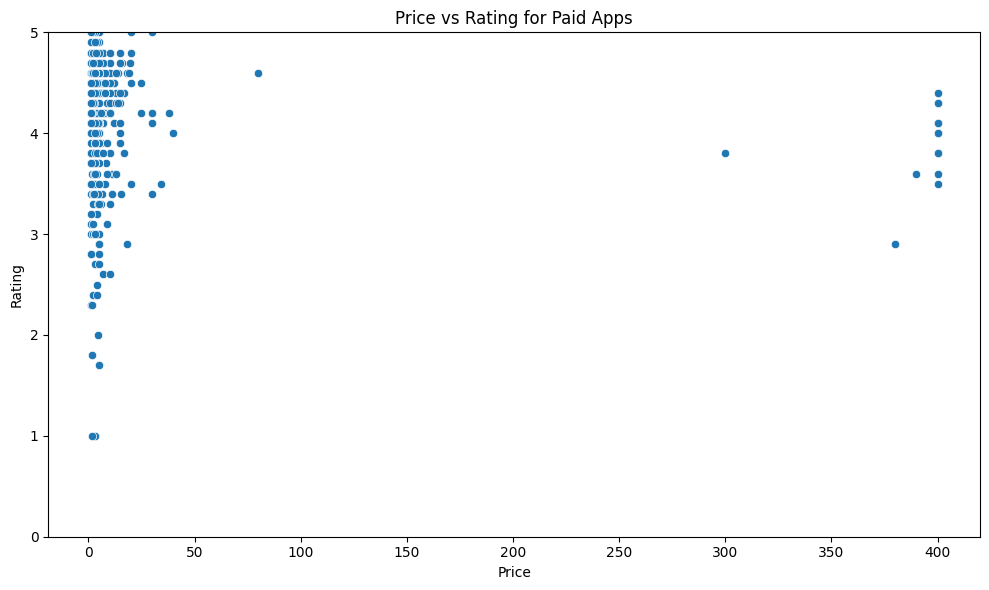

In [24]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=paid_apps,
    x='Price',
    y='Rating'
)

plt.title('Price vs Rating for Paid Apps')
plt.xlabel('Price')
plt.ylabel('Rating')

plt.ylim(0, 5)
plt.tight_layout()
plt.show()

In [ ]:
#Insights
#The correlation between app price and rating is -0.11, indicating a very weak negative relationship. This suggests that higher-priced apps do not necessarily receive better ratings, and pricing alone is not a strong determinant of user satisfaction.

In [25]:
#Category-wise User Engagement Analysis
#8.Which app categories have the highest user engagement based on reviews?
category_engagement = (
    df.groupby('Category')['Reviews']
      .sum()
      .sort_values(ascending=False)
)

print(category_engagement)

Category
GAME                   623674697
FAMILY                 346010311
COMMUNICATION          285828897
TOOLS                  229424528
SOCIAL                 227927801
PHOTOGRAPHY            105351270
VIDEO_PLAYERS           67644190
SPORTS                  59407193
PRODUCTIVITY            55590649
PERSONALIZATION         53543080
SHOPPING                44551730
ENTERTAINMENT           34762650
TRAVEL_AND_LOCAL        26819741
NEWS_AND_MAGAZINES      23130228
HEALTH_AND_FITNESS      21361355
MAPS_AND_NAVIGATION     17729148
BOOKS_AND_REFERENCE     16721314
EDUCATION               13364148
FINANCE                 12662106
WEATHER                 12295164
LIFESTYLE               11832671
BUSINESS                 9890245
FOOD_AND_DRINK           6325028
DATING                   3623544
COMICS                   2342071
HOUSE_AND_HOME           1929847
ART_AND_DESIGN           1419203
MEDICAL                  1287612
AUTO_AND_VEHICLES        1163666
PARENTING                 958331
L

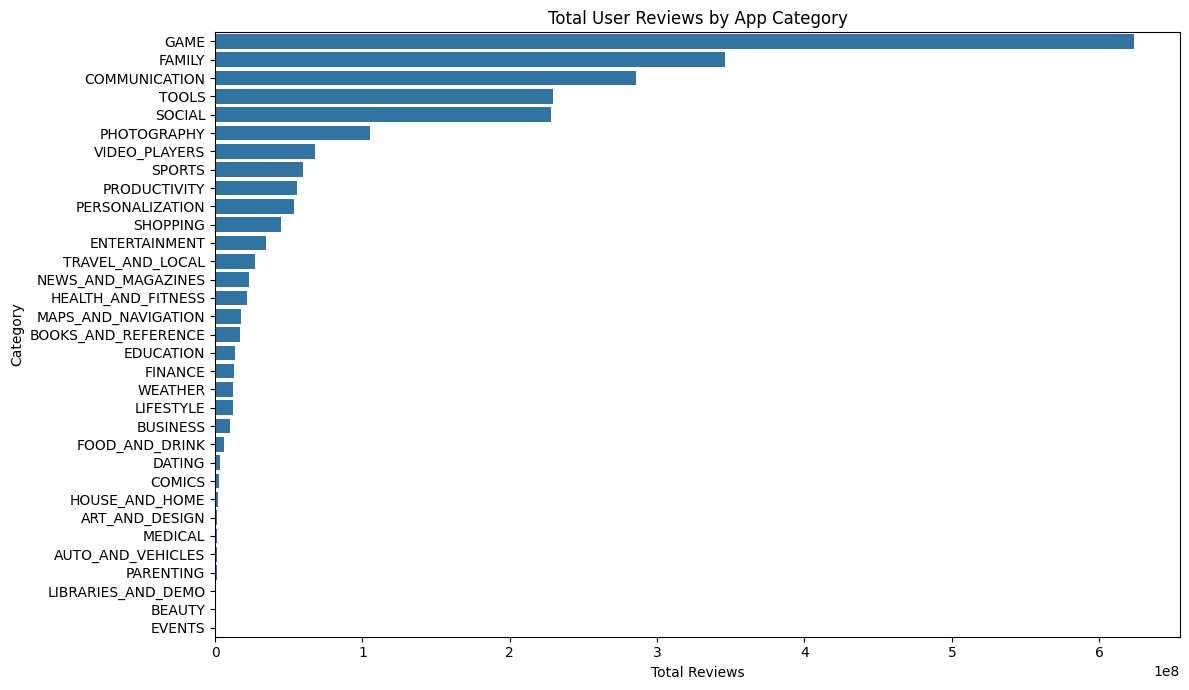

In [26]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x=category_engagement.values,
    y=category_engagement.index
)

plt.title('Total User Reviews by App Category')
plt.xlabel('Total Reviews')
plt.ylabel('Category')

plt.tight_layout()
plt.show()

In [ ]:
#Insights
#GAME has the highest user engagement with approximately 623.67 million reviews, followed by FAMILY and COMMUNICATION. This highlights strong user interaction in gaming, communication, and social apps, while categories such as EVENTS and BEAUTY show comparatively lower engagement.

In [32]:
#App Type & Engagement
#9.Do Free and Paid apps differ in user engagement?
type_engagement = df.groupby('Type').agg(
    Average_Reviews=('Reviews', 'mean'),
    Average_Installs=('Installs', 'mean')
).round(2)

type_engagement

,Average_Reviews,Average_Installs
Type,,
Free,257445.96,8889480.60
Paid,8742.92,76340.21


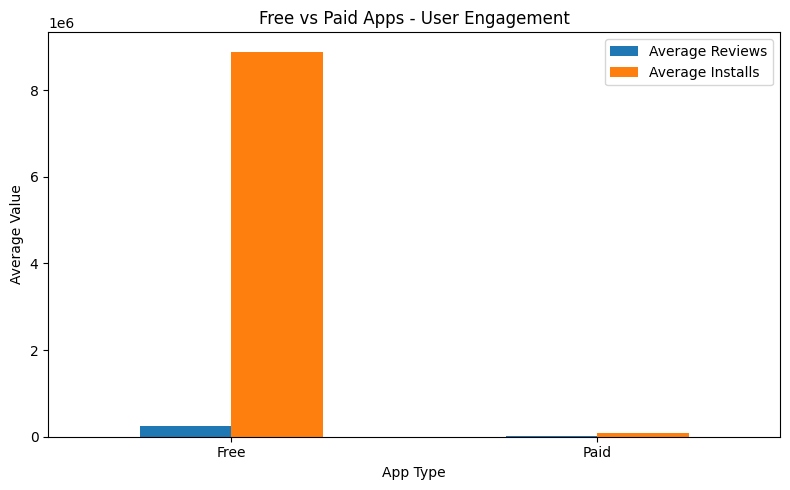

In [33]:
type_engagement.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Free vs Paid Apps - User Engagement')
plt.xlabel('App Type')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.legend(['Average Reviews', 'Average Installs'])

plt.tight_layout()
plt.show()

In [ ]:
#Insights
#Free apps show significantly higher user engagement than paid apps, with approximately 116× higher average installs and 29× higher average reviews. This suggests that free access is strongly associated with greater user reach and engagement in this dataset.

In [34]:
#High-Performing Apps Analysis
#10.Which apps are the highest-performing based on Rating, Reviews, and Installs?
top_apps = df.nlargest(10, 'Installs')[
    ['App', 'Rating', 'Reviews', 'Installs']
]

top_apps

,App,Rating,Reviews,Installs
152,Google Play Books,3.9,1433233,1000000000
299,Messenger – Text and Video Chat for Free,4.0,56642847,1000000000
300,WhatsApp Messenger,4.4,69119316,1000000000
302,Google Chrome: Fast & Secure,4.3,9642995,1000000000
304,Gmail,4.3,4604324,1000000000
305,Hangouts,4.0,3419249,1000000000
349,Skype - free IM & video calls,4.1,10484169,1000000000
702,Google Play Games,4.3,7165362,1000000000
1357,Subway Surfers,4.5,27722264,1000000000
2025,Facebook,4.1,78158306,1000000000


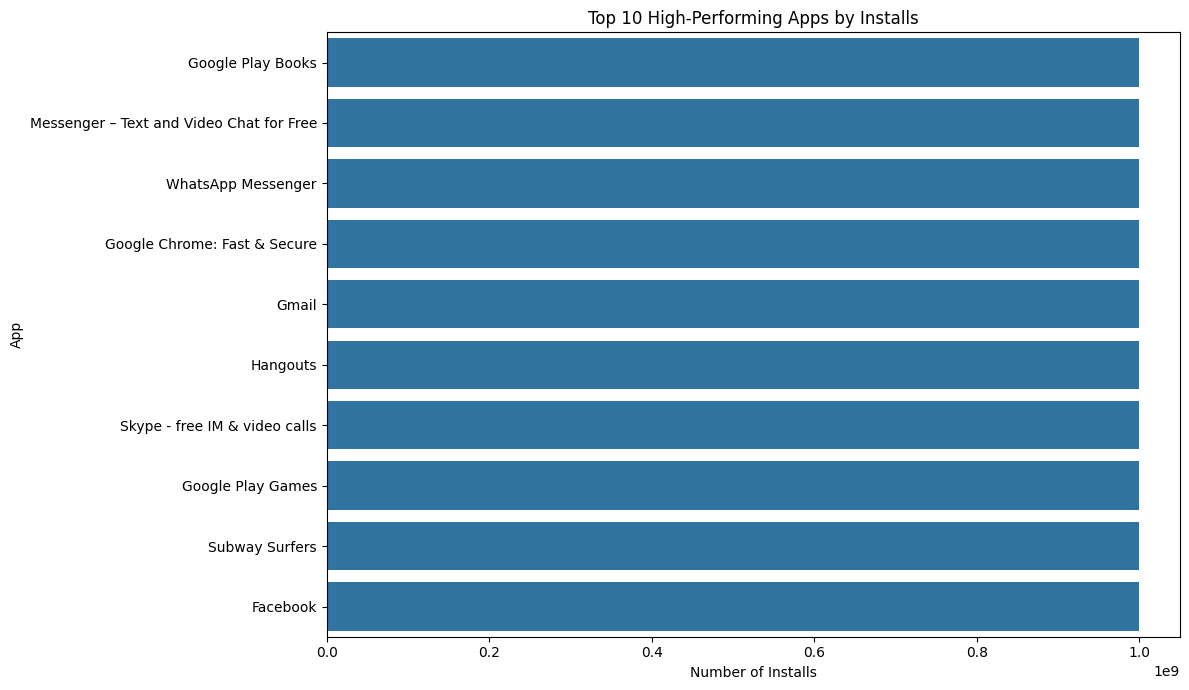

In [35]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_apps,
    x='Installs',
    y='App'
)

plt.title('Top 10 High-Performing Apps by Installs')
plt.xlabel('Number of Installs')
plt.ylabel('App')

plt.tight_layout()
plt.show()

In [ ]:
#Insights
#All top-performing apps have 1 billion recorded installs, indicating exceptional market reach. Facebook leads in user reviews, while Subway Surfers has the highest rating (4.5), showing that popularity and user satisfaction are not always the same.

In [36]:
#Overall KPIs
print("Total Apps:", df['App'].nunique())
print("Average Rating:", round(df['Rating'].mean(), 2))
print("Total Reviews:", df['Reviews'].sum())
print("Total Installs:", df['Installs'].sum())

Total Apps: 9659
Average Rating: 4.18
Total Reviews: 2320036507
Total Installs: 79938738527


In [44]:
df.to_csv(
    r"C:\Users\ujjai\Desktop\Jupyter Projects\google_playstore_cleaned.csv",
    index=False
)

print("File saved successfully!")

File saved successfully!


In [45]:
import os

file_path = r"C:\Users\ujjai\Desktop\Jupyter Projects\google_playstore_cleaned.csv"

print(os.path.exists(file_path))

True


In [46]:
check_df = pd.read_csv(
    r"C:\Users\ujjai\Desktop\Jupyter Projects\google_playstore_cleaned.csv"
)

print("Rows:", len(check_df))
print("Columns:", len(check_df.columns))

Rows: 9745
Columns: 10
